# Fine Tuning BERT for Emotion Classification


In [1]:
# Dependencies

!pip install datasets

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.nn import CrossEntropyLoss
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer
from transformers import DataCollatorWithPadding
from transformers import EarlyStoppingCallback
from transformers import Trainer
from transformers import TrainingArguments


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.get_device_name(0))

NVIDIA A100-SXM4-40GB


## Load Data

In [3]:
df = pd.read_csv('/content/augmented_emotions.csv')

In [4]:
df.head()

,id,artist,seq,song,label_name
0,54565,Badly Drawn Boy,"Don't want to give, Don't want to steal Don't ...","Above You, Below Me",fear
1,9010,John Waite,The day begins with CNN And it looks like WWII...,Have You Seen Her My Friend?,fear
2,7566,The Roots,"Step into the realm, you're bound to get caugh...",Step Into the Relm,fear
3,33618,Meshuggah,"How come I shiver, hurt and bleed, If in dream...",Pineal Gland Optics,fear
4,56535,Cocteau Twins,"Flaxen, the dress is born Crush a crushing sto...",Alas Dies Laughing,fear


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20591 entries, 0 to 20590
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          20591 non-null  int64 
 1   artist      20591 non-null  object
 2   seq         20591 non-null  object
 3   song        20591 non-null  object
 4   label_name  20591 non-null  object
dtypes: int64(1), object(4)
memory usage: 804.5+ KB


In [6]:
df["label_name"].value_counts()

,count
label_name,
anger,4045
fear,4000
sadness,4000
joy,3643
surprise,2990
disgust,1913


## Tokenize

In [7]:
model_name = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [8]:
emotions = df["label_name"].unique()
emotions

array(['fear', 'sadness', 'anger', 'disgust', 'joy', 'surprise'],
      dtype=object)

In [9]:
label2id = {emotion:i for i, emotion in enumerate(emotions)}
id2label = {v:k for k, v in label2id.items()}
print(label2id)
print(id2label)

{'fear': 0, 'sadness': 1, 'anger': 2, 'disgust': 3, 'joy': 4, 'surprise': 5}
{0: 'fear', 1: 'sadness', 2: 'anger', 3: 'disgust', 4: 'joy', 5: 'surprise'}


In [10]:
df["label"] = df["label_name"].map(label2id)

In [11]:
def tokenize_function(examples):
    return tokenizer(examples["seq"], padding="max_length", truncation=True, max_length=512)

In [12]:
train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label_name'])
test, validation = train_test_split(test, test_size=1/2, random_state=42, stratify=test['label_name'])

In [13]:
train_dataset = Dataset.from_pandas(train)
val_dataset = Dataset.from_pandas(validation)
test_dataset = Dataset.from_pandas(test)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/16472 [00:00<?, ? examples/s]

Map:   0%|          | 0/2060 [00:00<?, ? examples/s]

Map:   0%|          | 0/2059 [00:00<?, ? examples/s]

## Model

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
batch_size = 64

training_args = TrainingArguments(
    output_dir="/content/models",           # Directory for saving model checkpoints
    eval_strategy="epoch",     # Evaluate at the end of each epoch
    learning_rate=2e-5,              # Start with a small learning rate
    per_device_train_batch_size=batch_size,  # Batch size per GPU
    per_device_eval_batch_size=batch_size,
    num_train_epochs=10,              # Number of epochs
    weight_decay=0.05,               # Regularization
    load_best_model_at_end=True,     # Automatically load the best checkpoint
    save_strategy="epoch",
    warmup_ratio=0.1,
    metric_for_best_model="f1_weighted",         # En iyi modeli F1 skoruna göre seç
    greater_is_better=True,            # F1 büyükse daha iyidir
    lr_scheduler_type="cosine_with_restarts",
    label_smoothing_factor=0.1,
    fp16=True                        # Enable mixed precision for faster training
)

In [16]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average='macro'
    )
    f1_weighted = f1_score(labels, preds, average='weighted')
    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "f1_weighted": f1_weighted,
        "f1_macro": f1_macro,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro
    }

In [17]:
# Compute Class Weights & Create Trainer Model

labels = train_dataset['label']
num_classes = len(set(labels))

label_counts = Counter(labels)
class_counts = np.array([label_counts[i] for i in range(num_classes)])

class_weights = compute_class_weight(class_weight='balanced', classes=np.arange(num_classes), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float)

print(class_weights)
print(class_weights.sum())
print(class_weights.dtype)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

tensor([0.8579, 0.8579, 0.8484, 1.7943, 0.9421, 1.1477])
tensor(6.4484)
torch.float32


In [18]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: myelman17 (myelman17-y-ld-z-technical-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro,Precision Macro,Recall Macro
1,No log,1.038328,0.606796,0.588736,0.589321,0.608972,0.616043
2,1.178500,0.628409,0.770874,0.771420,0.772219,0.774413,0.773933
3,1.178500,0.565993,0.795631,0.796439,0.793646,0.794355,0.804486
4,0.371100,0.557171,0.802913,0.802149,0.803443,0.799258,0.813922
5,0.371100,0.601159,0.812621,0.811153,0.813931,0.808814,0.822150
6,0.138100,0.634765,0.820388,0.819905,0.825228,0.821852,0.829472
7,0.138100,0.697926,0.823301,0.823145,0.828173,0.827057,0.830300
8,0.051600,0.730991,0.817961,0.817792,0.820850,0.818434,0.825090
9,0.051600,0.745294,0.822816,0.822429,0.827286,0.825872,0.829410


TrainOutput(global_step=2322, training_loss=0.3781448227901278, metrics={'train_runtime': 701.9958, 'train_samples_per_second': 234.645, 'train_steps_per_second': 3.675, 'total_flos': 3.900708860033434e+16, 'train_loss': 0.3781448227901278, 'epoch': 9.0})

# Evaluate

In [19]:
preds_output = trainer.predict(test_dataset)
preds_output.metrics

{'test_loss': 0.713262140750885,
 'test_accuracy': 0.8232151529868869,
 'test_f1_weighted': 0.8231890929404834,
 'test_f1_macro': 0.8305851157805383,
 'test_precision_macro': 0.8297710930685395,
 'test_recall_macro': 0.8322182955574582,
 'test_runtime': 4.0196,
 'test_samples_per_second': 512.236,
 'test_steps_per_second': 8.21}

In [20]:
y_pred = np.argmax(preds_output.predictions, axis = 1)
y_true = test[:]['label']

print(classification_report(y_true, y_pred, target_names=emotions))

              precision    recall  f1-score   support

        fear       0.71      0.76      0.73       400
     sadness       0.82      0.80      0.81       400
       anger       0.82      0.76      0.79       404
     disgust       0.85      0.89      0.87       192
         joy       0.89      0.92      0.91       364
    surprise       0.87      0.87      0.87       299

    accuracy                           0.82      2059
   macro avg       0.83      0.83      0.83      2059
weighted avg       0.82      0.82      0.82      2059



In [21]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
trainer.save_model("/content/drive/MyDrive/Colab Notebooks/BERT Models/BERT")

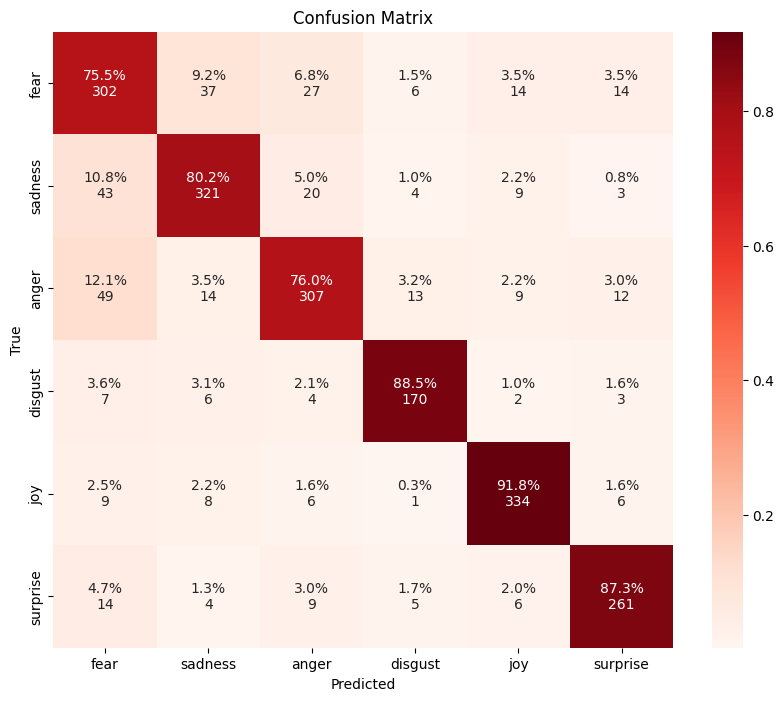

In [23]:
# Plot Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

labels = np.array([
    [f"{cm_normalized[i, j]*100:.1f}%\n{cm[i, j]}" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=labels, fmt="", cmap="Reds", xticklabels=emotions, yticklabels=emotions)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()